# Get started
## Planner of Transits Observation - PTO
This is a tutorial example for using PTO. The purpose of this code is to calculate transit windows (emission observations to be added soon) for given time period and location to observe from. It can be used for proposal writing, and further for preparation of the observations.

The main steps in PTO are:

1. Load a catalog of planets

2. Filter the catalog to desired target

3. Calculate transit windows

4. Plot observing conditions for each night for given location

<div class="alert alert-block alert-info">
<b>Tip:</b> Generally, most functions and methods are well documented. You can get a hint by hovering mouse over the function name. You can also get the documentation by help(`function_name`).
</div>

<div class="alert alert-block alert-info">
<b>Tip:</b> Full documentation is available at <a href= "https://pto.readthedocs.io/en/latest/">PTO documentation</a>.
</div>



Lets first supress warnings - most of the warnings are safe to ignore, and include performance warnings or very fine precision warnings outside the level needed for this code.

In [1]:
import warnings
warnings.filterwarnings('ignore')

## 1. Load a catalog of planets
`PTO` allows the user to load a catalog of exoplanets. Different databases will be added, but we will use the default NASA composite table. To do so, we can do: 

In [2]:
from PTO.database.NASA_exoplanet_archive import NASA_Exoplanet_Archive_CompositeDefault

Catalog = NASA_Exoplanet_Archive_CompositeDefault()
Catalog.load_API_table()

  INFO     | Trying to load NASA Exoplanet Archive Composite table
  INFO     | Filename: /media/chamaeleontis/Observatory_main/Code/observations_transits/PTO/docs/source/saved_files/CatalogComposite.pkl


## Logging:
A logger is implemented in `PTO` to showcase progress of the code run. These are divided in different levels, based on importance. For now, feel free to ignore the messages.

## Auto-save:
As the TAP queries take some time, many functions and classes have a auto-save/load feature. In those cases a time interval (typically 1 week) is given to rerun all queries. 

## Calculation of related parameters:
NASA exoplanet archive typically does not calculate any related parameters, even if it can. The `Catalog` classes have a `_get_all()` method that is run immediatelly after loading the data. This will recalculate those values, including the error, for multiple parameters. For example, a unit conversion between Earth and Jupiter is not always provided, which can lead to some planets being ignored unintentionally when filtering. The conversion is never done on entries where the value already exists.

<div class="alert alert-block alert-warning">
<b>Warning:</b> Due to limitations of astropy nddata package, the error propagation is done on maximum of the lower and upper error. This means, that if the uncertainty of a parameter is unequal, the resulting uncertainty is going to be larger than necessary. 
</div>

For transit related parameters, a `Flag.Transit` is enforced to be true in order to calculate the parameters. This means, that although you can in principle calculate $b$ (impact parameter) as long as you have $i$ (inclination) $R_s$ (Stellar radius) and $a$ (semimajor axis), it won't be calculated unless the transits were detected.

## Keys available
As there are many different parameters, few convenience functions are provided to list all available keys in the main table.

To print all keys, you can use `Catalogue.print_all_keys()`.
For a particular set of keys, you can use:
- `Catalogue.print_position_keys()`

- `Catalogue.print_system_keys()`

- `Catalogue.print_star_keys()`

- `Catalogue.print_planet_keys()`

- `Catalogue.print_discovery_keys()`

- `Catalogue.print_magnitude_keys()`

- `Catalogue.print_flag_keys()`



In [3]:
Catalog.print_all_keys()

  PRINT    | =========================
  PRINT    | Position keys:
  PRINT    | =========================
  PRINT    | Position.Declination
  PRINT    | Position.Declination.Reference
  PRINT    | Position.Declination.Error.Upper
  PRINT    | Position.Declination.Error.Lower
  PRINT    | Position.EclipticLatitude
  PRINT    | Position.EclipticLatitude.Reference
  PRINT    | Position.EclipticLatitude.Error.Upper
  PRINT    | Position.EclipticLatitude.Error.Lower
  PRINT    | Position.EclipticLongitude
  PRINT    | Position.EclipticLongitude.Reference
  PRINT    | Position.EclipticLongitude.Error.Upper
  PRINT    | Position.EclipticLongitude.Error.Lower
  PRINT    | Position.GalacticLatitude
  PRINT    | Position.GalacticLatitude.Reference
  PRINT    | Position.GalacticLatitude.Error.Upper
  PRINT    | Position.GalacticLatitude.Error.Lower
  PRINT    | Position.GalacticLongitude
  PRINT    | Position.GalacticLongitude.Reference
  PRINT    | Position.GalacticLongitude.Error.Upper
  PRINT 

As you can see, there is particular system to the key names:
First, there are 7 types of parameters:

1. `Position`
 - Position of host star on the sky. Rarely used in filtering, but important for the transit window plot.
2. `System`
 - Parameters related to the system, in particular the systemic velocity and the distance
3. `Star`
 - Stellar parameters of the host star. If multiple stars are present in this system, the primary star is selected.
4. `Planet`
 - Planetary parameters.
5. `Magnitude`
 - Magnitude of the host star
6. `Flag`
 - Several flags available in the table. Typically, these include whether the planets were detected by specific method, like transits. Several functions use this to filter down only transiting planets.

Second, most parameters have four keys.

1. `Parameter`
 - The value of parameter
2. `Parameter.Error.Lower`
 - The lower (-) error of the parameter
3. `Parameter.Error.Upper`
 - The upper (+) error of the parameter
4. `Parameter.Reference`
 - Reference for the given parameter


### Filtering specific planet
To get a single planet, we can filter out the table attribute of the Catalog class. This is a standard pandas DataFrame type table. Lets get the sample for HD 209458 b.

<div class="alert alert-block alert-info">
<b>Tip:</b> Because the attribute for the filtering is pandas DataFrame, you can use any of the pandas function on it (intended for DataFrame). More info available in the Filtering notebook.
</div>


In [4]:
Catalog.table = Catalog.table[Catalog.table['Planet.Name'] == 'HD 209458 b']

## Plotting the sample:
There are several functions provided to plot the exoplanet population and (further) filtered target sample.

The idea behind the plotting functions is that multiple (over-)plots can be done on the same figure. To do so, the `plt.Axes` artist (typically `ax`), can be passed to all plot functions. By default, if `ax` is not passed, a new plot gets created instead.

As there are many aspects of the plot that can be changed, the resulting `ax` is always returned. This allows for further modification (like linear vs log scales of axis) outside the functions.

Let's make a plot usable for proposal. For this case, we will focus on a plot targeting HD 209458 b.

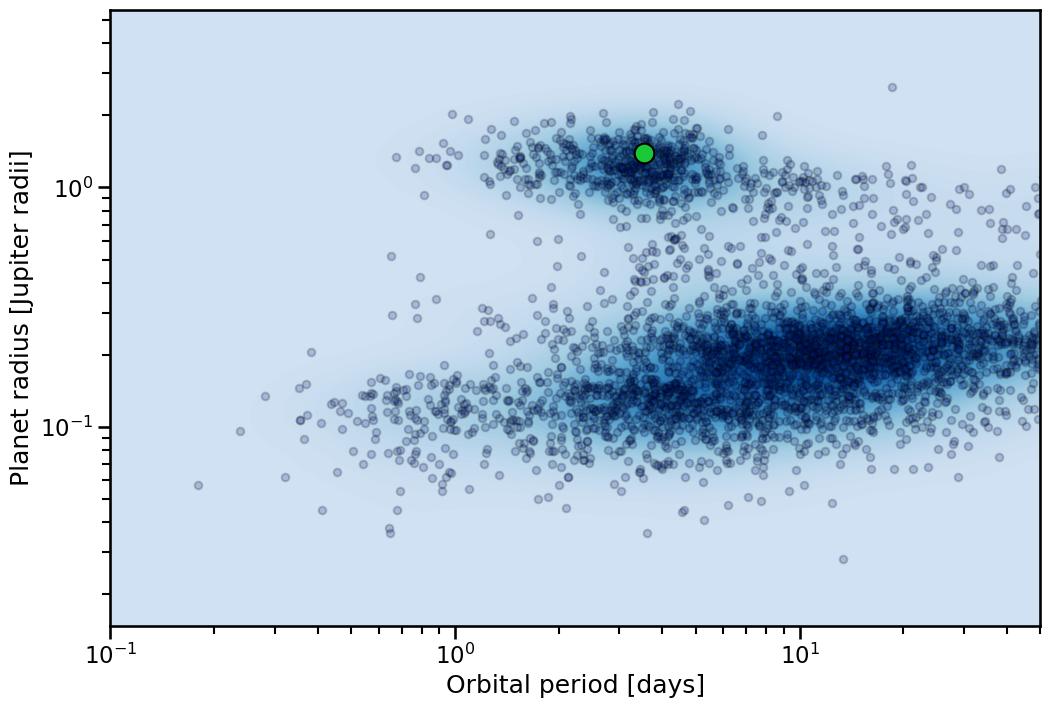

In [5]:
import seaborn as sns

with sns.plotting_context('talk'):
    fig, ax = Catalog.highlight_sample(
        x_key = 'Planet.Period',
        y_key = 'Planet.RadiusJupiter',
    )
    ax.set_xlim(0.1,50) # Set to max of 50 days.


## Calculation of transit windows
Lets now calculate all transit windows. By default, we will get transits windows in the next year.

In [6]:
from PTO.transits.windows import Windows
Transits = Windows(
    table = Catalog.table,
    directory= './HD209458b/',
)

  WARNING  | petitRADTRANS instalation not found. Please install petitRADTRANS to use the PTO.simulations module.
  INFO     | =========================
  INFO     | Set observing period:
  INFO     |     2024-11-19 12:00:00.000
  INFO     |     2025-11-19 12:00:00.000
  INFO     | =========================
  INFO     | About to calculate event midpoints for 1 planets


This doesn't seem to do much at a glance. However, it calculates all transit events for all planets for further use. We can check the possible windows by printing all the windows.

In [7]:
Transits.print_windows()

  PRINT    | =========================
  PRINT    | Transit windows centers for HD 209458 b
  PRINT    |     2460637.47207873 ± 1.39 min | 2024-11-22 23:19 UT
  PRINT    |     2460640.9968273197 ± 1.39 min | 2024-11-26 11:55 UT
  PRINT    |     2460644.52157591 ± 1.40 min | 2024-11-30 00:31 UT
  PRINT    |     2460648.0463245 ± 1.40 min | 2024-12-03 13:06 UT
  PRINT    |     2460651.5710730897 ± 1.40 min | 2024-12-07 01:42 UT
  PRINT    |     2460655.09582168 ± 1.40 min | 2024-12-10 14:17 UT
  PRINT    |     2460658.62057027 ± 1.40 min | 2024-12-14 02:53 UT
  PRINT    |     2460662.1453188597 ± 1.40 min | 2024-12-17 15:29 UT
  PRINT    |     2460665.67006745 ± 1.40 min | 2024-12-21 04:04 UT
  PRINT    |     2460669.19481604 ± 1.40 min | 2024-12-24 16:40 UT
  PRINT    |     2460672.7195646297 ± 1.40 min | 2024-12-28 05:16 UT
  PRINT    |     2460676.24431322 ± 1.40 min | 2024-12-31 17:51 UT
  PRINT    |     2460679.76906181 ± 1.40 min | 2025-01-04 06:27 UT
  PRINT    |     2460683.29381

That looks like a lot of windows! Given the short period of HD 209458 b (3.5 days), we expect about 100 events in a year time!

However...

## Plotting the transit window
Lets now plot the observability of transit windows for Paranal.

In [8]:
import PTO.telescopes.telescopes as tel
Transits.generate_observability(
    location= tel.VLT,
)

  PRINT    | =========================
  PRINT    | Working on HD 209458 b
  PRINT    |     with Tc: 2451659.93742, P: 3.52474859 days and T14: 3.072 hours
  PRINT    | =========================
  INFO     |         Transit on: 20250730 - Quality: 1; Uncertainty: 1.43 min
  INFO     |         Transit on: 20250928 - Quality: 3; Uncertainty: 1.44 min


You can see the logger is automatically printing the main info about the planet and ephemeris. It also include the precision on the transit center - beware that sometimes the transit can be uncertain enough that the plot is meaningless.

Well, why do we have only 2 windows, when we had 100 opportunities?
Turns out for Paranal (VLT location), HD 209458 b is not that great target. It is fairly north, with declination of +19 deg. VLT is on the other hand around -20 deg. This means the host star is always quite low on the horizon, even during the best time. 

`PTO` automatically filters out windows where:

1. Star is not visible.
2. Full transit cannot be observed (there is partial keyword to allow partial transits, but by default it is disabled).
3. No baseline can be observed.

The observability is defined by:

1. Within the full night (defined by Sun altitude)
2. Within the airmass limit (2.2, for ESPRESSO) 

Both calculated windows look like this:

![Q3_20250731_HD209458b](Q3_20250731_HD209458b.png)
![Q8_20250929_HD209458b](Q8_20250929_HD209458b.png)

Tip: By default, a working directory is used to save the transit window plots. You can adjust this by setting the `directory` attribute in `Windows` class.